In [7]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

model="deepseek-r1-distill-llama-70b"
llm=ChatGroq(model_name=model,
             temperature=0
             )


In [ ]:
response = llm.invoke("Hello")
response

AIMessage(content='<think>\n\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 4, 'total_tokens': 20, 'completion_time': 0.078406376, 'prompt_time': 5.7089e-05, 'queue_time': 0.053743165999999995, 'total_time': 0.078463465}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run--9a3bf4b3-3fd3-4e2c-90d9-2bc71da88f73-0', usage_metadata={'input_tokens': 4, 'output_tokens': 16, 'total_tokens': 20})

#### These are custom tools

In [26]:
from langchain.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    '''
    Multiply two integers

    Args:
    a (int): The first integer
    b (int): The second integer

    Returns:
        int: The result of multiplication
    '''
    return a*b

@tool
def add(a: int, b: int) -> int:
    '''
    Add two integers

    Args:
    a (int): The first integer
    b (int): The second integer

    Returns:
        int: The result of addition
    '''
    return a+b

@tool
def divide(a: int, b: int) -> float:
    '''
    Divide two integers

    Args:
    a (int): The first integer
    b (int): The second integer

    Returns:
        int: The result of division
    '''
    if b == 0:
        raise ValueError("Denominator cannot be zero.")
    return a / b
    

#### These are Inbuilt tool

In [12]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun() ## This gives summary, tavily gives raw data

In [13]:
search.invoke("Stock price of VEERKRUPA")

"Veerkrupa Jewellers Share Price - Track LIVE BSE/NSE stock prices of Veerkrupa Jewellers with insights on performance, fundamentals, market cap, shareholding, financials, company profile, balance sheet, annual and quarterly reports, profit and loss. Find the latest Veerkrupa Jewellers Limited (VEERKRUPA.BO) stock quote, history, news and other vital information to help you with your stock trading and investing. Veerkrupa Jewellers Share Price Today 6 Jun 2025: Track Veerkrupa Jewellers share price today on NSE/BSE with real-time updates. Check stock performance, fundamentals, market cap, shareholding ... Get the latest Veerkrupa Jewellers Limited (BOM: 543545) stock price quote with financials, statistics, dividends, charts and more. Last 12 Months: Veerkrupa Jewellers Ltd share price moved down by 25.18% on BSE. 2. How can I quickly analyse the performance of the Veerkrupa Jewellers Ltd stock?The performance of the Veerkrupa Jewellers Ltd stock can be quickly analysed on the followin

In [ ]:
from langchain.tools import Tool

tools = [multiply, add, divide, search, get_stock_price]
llm_with_tools = llm.bind_tools(tools)

##### Testing

In [34]:
response = llm_with_tools.invoke("Hello")
print(response.content)
print(response.tool_calls)

Hello! How can I assist you today?
[]


In [ ]:
response = llm_with_tools.invoke("What is 2+2")
print(response.content)
print(response.tool_calls)


[{'name': 'divide', 'args': {'a': 2, 'b': 2}, 'id': '83r9mr3cr', 'type': 'tool_call'}]


In [37]:
response = llm_with_tools.invoke("What is the current age of Ratan Tata")
print(response.content)
print(response.tool_calls)


[{'name': 'duckduckgo_search', 'args': {'query': 'Ratan Tata age'}, 'id': 'stdnzkkqc', 'type': 'tool_call'}]


##### Orchestration

In [ ]:
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

SYSTEM_PROMPT = "You are a helpful assistant tasked with using search and performing arithmetic operations on a set of inputs."
def function_1(state: MessagesState):
    question = state['messages']
    input_question = [SYSTEM_PROMPT] + question
    response = llm_with_tools.invoke(input_question)

    return {"messages": [response]}

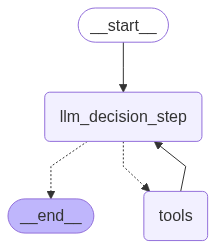

In [62]:
builder = StateGraph(MessagesState)
builder.add_node("llm_decision_step", function_1)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm_decision_step")
builder.add_conditional_edges("llm_decision_step",
                              tools_condition
                              )
builder.add_edge("tools", "llm_decision_step")

react_graph = builder.compile()

display(Image(react_graph.get_graph().draw_mermaid_png()))

In [63]:
message = [HumanMessage(content = "What is 2 times of Narendra Modi's age?")]
react_graph.invoke({"messages": message})

{'messages': [HumanMessage(content="What is 2 times of Narendra Modi's age?", additional_kwargs={}, response_metadata={}, id='ee30343c-5e5a-46f5-b20d-09dbe55c5123'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '8kz8g60rp', 'function': {'arguments': '{"query":"Narendra Modi age 2023"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 263, 'prompt_tokens': 396, 'total_tokens': 659, 'completion_time': 0.977258285, 'prompt_time': 0.027140436, 'queue_time': 0.064977853, 'total_time': 1.004398721}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--1e3873b6-d9f0-4c6c-88e5-f2d881ebe20c-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Narendra Modi age 2023'}, 'id': '8kz8g60rp', 'type': 'tool_call'}], usage_metadata={'input_tokens': 396, 'output_tokens': 263, 'total_tokens': 659}),
  ToolMessage(content="

In [64]:
message = [HumanMessage(content = "What is the networth of Elon Musk, and divide it by 2")]
react_graph.invoke({"messages": message})

{'messages': [HumanMessage(content='What is the networth of Elon Musk, and divide it by 2', additional_kwargs={}, response_metadata={}, id='c0984370-96ce-4b66-ac90-c793fa0afbe2'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '13x4n8hka', 'function': {'arguments': '{"query":"Elon Musk net worth 2023"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 292, 'prompt_tokens': 400, 'total_tokens': 692, 'completion_time': 1.070836865, 'prompt_time': 0.033547798, 'queue_time': 0.05420845400000001, 'total_time': 1.104384663}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f9bfc8f0-ce9a-428b-93c7-235e1f6f0cc4-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Elon Musk net worth 2023'}, 'id': '13x4n8hka', 'type': 'tool_call'}], usage_metadata={'input_tokens': 400, 'output_tokens': 292, 'total_tokens': 692}

In [65]:
message = [HumanMessage(content = "What is the speed of light in m/s and multiply it by 10")]
react_graph.invoke({"messages": message})

{'messages': [HumanMessage(content='What is the speed of light in m/s and multiply it by 10', additional_kwargs={}, response_metadata={}, id='93e3082a-ae24-4454-bf19-8e65014bc352'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6hhmp72dk', 'function': {'arguments': '{"a":299792458,"b":10}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 404, 'prompt_tokens': 400, 'total_tokens': 804, 'completion_time': 1.611760953, 'prompt_time': 0.025751604, 'queue_time': 0.054270766, 'total_time': 1.637512557}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--1c5b9da2-3a3f-489b-8fdb-f0771c652bec-0', tool_calls=[{'name': 'multiply', 'args': {'a': 299792458, 'b': 10}, 'id': '6hhmp72dk', 'type': 'tool_call'}], usage_metadata={'input_tokens': 400, 'output_tokens': 404, 'total_tokens': 804}),
  ToolMessage(content='2997924580', name='multi

In [66]:
message = [HumanMessage(content = "If Ayush takes choco from Sumit and Ratnesh, What is Ayush's body count?")]
react_graph.invoke({"messages": message})

{'messages': [HumanMessage(content="If Ayush takes choco from Sumit and Ratnesh, What is Ayush's body count?", additional_kwargs={}, response_metadata={}, id='702cf648-da14-4b74-8bf8-ebf4e8605428'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7ymqrdgcb', 'function': {'arguments': '{"a":1,"b":1}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 311, 'prompt_tokens': 407, 'total_tokens': 718, 'completion_time': 1.130909091, 'prompt_time': 0.032904552, 'queue_time': 0.053344748000000004, 'total_time': 1.1638136430000001}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--cab23da4-e121-4739-95f5-ee5a105ff0af-0', tool_calls=[{'name': 'add', 'args': {'a': 1, 'b': 1}, 'id': '7ymqrdgcb', 'type': 'tool_call'}], usage_metadata={'input_tokens': 407, 'output_tokens': 311, 'total_tokens': 718}),
  ToolMessage(content='2', name='add', id=

In [69]:
SYSTEM_PROMPT = SystemMessage(content = "You are a helpful assistant tasked with using search, the yahoo finance tool and performing arithmetic operations on a set of inputs.")
def function_1(state: MessagesState):
    question = state['messages']
    input_question = [SYSTEM_PROMPT] + question
    response = llm_with_tools.invoke(input_question)

    return {"messages": [response]}

In [71]:
import yfinance as yf

@tool
def get_stock_price(ticker: str) -> str:
    """
    Fetches the previous closing price of a given stock ticker from Yahoo Finance.

    Args:
        ticker (str): The stock ticker symbol (e.g., 'AAPL', 'TSLA', 'NIFTY.BO').

    Returns:
        str: A message with the stock's previous closing price.
    """
    try:
        stock = yf.Ticker(ticker)
        price = stock.info.get('previousClose')
        if price is None:
            return f"Could not fetch price for ticker '{ticker}'."
        return f"The last closing price of {ticker.upper()} was ${price:.2f}."
    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"

In [72]:
tools = [multiply, add, divide, search, get_stock_price]
llm_with_tools = llm.bind_tools(tools)

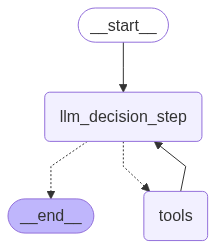

In [73]:
builder = StateGraph(MessagesState)
builder.add_node("llm_decision_step", function_1)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm_decision_step")
builder.add_conditional_edges("llm_decision_step",
                              tools_condition
                              )
builder.add_edge("tools", "llm_decision_step")

react_graph = builder.compile()

display(Image(react_graph.get_graph().draw_mermaid_png()))

In [ ]:
message = [HumanMessage(content = "?")]
response = react_graph.invoke({"messages": message})
response


HTTP Error 404: 


{'messages': [HumanMessage(content='What is the stock price of the bank with started by Unit Trust of India (UTI)?', additional_kwargs={}, response_metadata={}, id='54d16b9a-0aa5-4298-858d-f8a80f826f46'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '2pgshvfqw', 'function': {'arguments': '{"ticker":"UNIONBANK"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 337, 'prompt_tokens': 503, 'total_tokens': 840, 'completion_time': 1.225454545, 'prompt_time': 0.039154529, 'queue_time': 0.057562491, 'total_time': 1.264609074}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--554f7332-eca0-445c-9ced-e97ae064235e-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'UNIONBANK'}, 'id': '2pgshvfqw', 'type': 'tool_call'}], usage_metadata={'input_tokens': 503, 'output_tokens': 337, 'total_tokens': 840}),
  ToolMessag

#### Assignment

In [ ]:
# Assignment:
    
# AI Travel Agent & Expense Planner(Purpose: Trip planning for any city worldwide with Realtime data.")

# • Real-time weather information
# • Top attractions and activities
# • Hotel cost calculation (per day × total days)
# • Currency conversion to user's native currency
# • Complete itinerary generation
# • Total expense calculation
# • generate a summary of the entire output

# user_input
#   |
# search attraction and activity
# 1. search attracation
# 2. search restaurant
# 3. search activity
# 4. search transportation
#   |
# search weather forcasting
# 1. get current weather
# 2. get weather forcast
#   |
# search hotel costs
# 1. search hotel
# 2. estimate the hotel cost
# 3. budget_range
#   |
# calculate total cost
# 1. add
# 2. multiply
# 3. calculated total cost
# 4. calcualte the daily budget
#     | 
# currency_converion
# 1. get exchnage rate
# 2. convert currancy
#     | 
# Itinery generation
# 1. get day plan
# 2. crete full itinery
#     |
# create Trip Summary
#     |
# Retun complete traval plan

# Note: if you know the OOPS then design this entire system using object and class in modular fashion.


# deadline is till next friday 9PM IST


#  everyone you can submit the assignments in this form. MAke sure to have one GitHub link and put all the assignments there https://forms.gle/g8RZ4qx8yvNcih4B7    
    

In [114]:
class weather():
    def __init__(self, location):
        self.location = location
    
    def get_current_weather(self):
        return f"Current weather of {self.location}: 45"
    def get_weather_forcast(self):
        return f"It will be sunny in {self.location}"